In [1]:
import pandas as pd
print("hello world")


hello world


In [2]:
import requests
import pandas as pd

API_KEY = "51eead0d9ed64de3ac9048ffb92cdbdc"
stock_symbols = ['AAPL', 'GOOGL', 'MSFT', 'TSLA', 'AMZN', 'META']


In [3]:
def fetch_stock_data(symbol, api_key, outputsize="365"):
    url = f"https://api.twelvedata.com/time_series"
    params = {
        "symbol": symbol,
        "interval": "1day",
        "apikey": api_key,
        "outputsize": outputsize,
        "format": "JSON"
    }
    response = requests.get(url, params=params)
    data = response.json()
    if "values" in data:
        df = pd.DataFrame(data["values"])
        df["date"] = pd.to_datetime(df["datetime"])
        df = df.set_index("date")
        df = df.apply(pd.to_numeric, errors='ignore')
        return df
    else:
        print(f"Failed to fetch data for {symbol}: {data.get('message', 'Unknown error')}")
        return None

stock_data = {}
for symbol in stock_symbols:
    print(f"Fetching data for {symbol}...")
    df = fetch_stock_data(symbol, API_KEY)
    if df is not None:
        stock_data[symbol] = df


Fetching data for AAPL...


/var/folders/x2/zzlc6gjx425_qfb3j1dh0s6w0000gn/T/ipykernel_4613/2780902364.py:16: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


Fetching data for GOOGL...


/var/folders/x2/zzlc6gjx425_qfb3j1dh0s6w0000gn/T/ipykernel_4613/2780902364.py:16: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


Fetching data for MSFT...


...

/var/folders/x2/zzlc6gjx425_qfb3j1dh0s6w0000gn/T/ipykernel_4613/2780902364.py:16: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


Fetching data for AMZN...


/var/folders/x2/zzlc6gjx425_qfb3j1dh0s6w0000gn/T/ipykernel_4613/2780902364.py:16: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


Fetching data for META...


/var/folders/x2/zzlc6gjx425_qfb3j1dh0s6w0000gn/T/ipykernel_4613/2780902364.py:16: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


In [4]:
stock_data['AAPL'].head()


,datetime,open,high,low,close,volume
date,,,,,,
2025-10-31,2025-10-31,276.98999,277.32001,269.16000,270.37000,86096700
2025-10-30,2025-10-30,271.98999,274.14001,268.48001,271.39999,69886500
2025-10-29,2025-10-29,269.28000,271.41000,267.10999,269.70001,51086700
2025-10-28,2025-10-28,268.98999,269.89001,268.14999,269.00000,41534800
2025-10-27,2025-10-27,264.88000,269.12000,264.64999,268.81000,44888200


In [8]:
import yfinance as yf
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

stock = yf.Ticker("AAPL")
analyzer = SentimentIntensityAnalyzer()

news = stock.news

for article in news:
    # Safely extract title and summary (inside 'content')
    content = article.get('content', {})
    title = content.get('title', 'No Title')
    summary = content.get('summary', '')

    # Combine title + summary for stronger sentiment analysis
    text_to_analyze = f"{title}. {summary}"

    print(f"\nHeadline: {title}")
    sentiment = analyzer.polarity_scores(text_to_analyze)
    print(f"Sentiment: {sentiment}")


Headline: Apple (AAPL) Delivers Solid Beat — Jefferies Softens Bearish Stance
Sentiment: {'neg': 0.0, 'neu': 0.94, 'pos': 0.06, 'compound': 0.4939}

Headline: Here's What We Learned From Big Tech Earnings Last Week
Sentiment: {'neg': 0.0, 'neu': 0.844, 'pos': 0.156, 'compound': 0.743}

Headline: Warren Buffett Still Owns 400,000,000 Shares of This Iconic American Business
Sentiment: {'neg': 0.0, 'neu': 0.776, 'pos': 0.224, 'compound': 0.6369}

Headline: Alibaba Stock Has Soared More Than 110% This Year. Here's Why It Might Not Be Too Late to Invest.
Sentiment: {'neg': 0.073, 'neu': 0.86, 'pos': 0.067, 'compound': -0.0521}

Headline: 1 Unstoppable Stock to Buy Before It Joins Nvidia, Apple, Microsoft, and Alphabet in the $3 Trillion Club
Sentiment: {'neg': 0.04, 'neu': 0.842, 'pos': 0.118, 'compound': 0.5478}

Headline: Warren Buffett Is Leaving Berkshire Hathaway in Great Shape for His Successor After Profit Results
Sentiment: {'neg': 0.0, 'neu': 0.777, 'pos': 0.223, 'compound': 0.962

In [14]:
import yfinance as yf
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd

analyzer = SentimentIntensityAnalyzer()

def fetch_news_sentiment(symbol):
    stock = yf.Ticker(symbol)
    news = stock.news
    print(f"Number of news articles for {symbol}: {len(news)}")
    data = []

    for article in news:
        content = article.get('content', {})
        title = content.get('title', 'No Title')
        summary = content.get('summary', '')
        date = article.get('providerPublishTime', None)
        if date:
            date = pd.to_datetime(date, unit='s').date()
        else:
            continue
        text_to_analyze = f"{title}. {summary}"
        sentiment = analyzer.polarity_scores(text_to_analyze)['compound']  # Use compound only
        data.append({'date': date, 'sentiment': sentiment})

    df = pd.DataFrame(data)
    print(f"Sample sentiment data for {symbol}:")
    print(df.head())
    # Aggregate by date to get average daily sentiment
    daily_sentiment = df.groupby('date').mean().reset_index()
    print(f"Aggregated daily sentiment for {symbol}:")
    print(daily_sentiment.head())
    return daily_sentiment

def fetch_historical_data(symbol, period="1y"):
    stock = yf.Ticker(symbol)
    hist = stock.history(period=period)
    hist.reset_index(inplace=True)
    hist['date'] = hist['Date'].dt.date
    return hist[['date', 'Open', 'High', 'Low', 'Close', 'Volume']]

def combine_sentiment_and_prices(symbol):
    print(f"Processing {symbol}...")
    news_df = fetch_news_sentiment(symbol)
    price_df = fetch_historical_data(symbol)
    merged_df = pd.merge(price_df, news_df, on='date', how='left')
    print(f"Combined data for {symbol}:")
    print(merged_df.head(10))
    return merged_df

# Example usage for AAPL
combined_df = combine_sentiment_and_prices("AAPL")


Processing AAPL...
Number of news articles for AAPL: 10
Sample sentiment data for AAPL:
Empty DataFrame
Columns: []
Index: []


KeyError: 'date'

In [19]:
import yfinance as yf
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd
from datetime import date, timedelta

analyzer = SentimentIntensityAnalyzer()

def fetch_news_sentiment(symbol):
    stock = yf.Ticker(symbol)
    news = stock.news
    print(f"Number of news articles for {symbol}: {len(news)}")

    data = []
    for article in news:
        content = article.get('content', {})
        title = content.get('title', 'No Title')
        summary = content.get('summary', '')

        # Try multiple date fields
        date_value = article.get('providerPublishTime', None)
        if not date_value:
            pubDate = content.get('pubDate', None)
            displayTime = content.get('displayTime', None)
            date_str = pubDate or displayTime
            if date_str:
                try:
                    date_value = pd.to_datetime(date_str).date()
                except Exception:
                    date_value = None
            else:
                date_value = None
        else:
            date_value = pd.to_datetime(date_value, unit='s').date()

        if not date_value:
            continue

        text_to_analyze = f"{title}. {summary}"
        sentiment = analyzer.polarity_scores(text_to_analyze)['compound']
        data.append({'date': date_value, 'sentiment': sentiment})

    if not data:
        print(f"No valid dated news for {symbol}")
        return pd.DataFrame(columns=['date', 'sentiment'])

    df = pd.DataFrame(data)
    print(f"Sample sentiment data for {symbol}:")
    print(df.head())

    daily_sentiment = df.groupby('date').mean().reset_index()
    print(f"Aggregated daily sentiment for {symbol}:")
    print(daily_sentiment.head())
    return daily_sentiment


def fetch_historical_data(symbol, start_date=None):
    stock = yf.Ticker(symbol)
    if start_date:
        hist = stock.history(start=start_date, end=pd.Timestamp.today() + pd.Timedelta(days=1))
    else:
        hist = stock.history(period="2y", end=pd.Timestamp.today() + pd.Timedelta(days=1))

    hist.reset_index(inplace=True)
    hist['date'] = hist['Date'].dt.date
    return hist[['date', 'Open', 'High', 'Low', 'Close', 'Volume']]


def combine_sentiment_and_prices(symbol):
    print(f"\nProcessing {symbol}...")
    news_df = fetch_news_sentiment(symbol)

    # Shift sentiment one day earlier (news influences next market day)
    news_df['date'] = pd.to_datetime(news_df['date']) - pd.Timedelta(days=1)
    news_df['date'] = news_df['date'].dt.date

    start = date.today() - timedelta(days=730)
    price_df = fetch_historical_data(symbol, start_date=start)

    print(f"Price data date range for {symbol}: {price_df['date'].min()} to {price_df['date'].max()}")
    print(f"News data date range for {symbol}: {news_df['date'].min()} to {news_df['date'].max()}")

    merged_df = pd.merge(price_df, news_df, on='date', how='left')
    print(f"\nCombined Data for {symbol}:")
    print(merged_df.tail(10))
    return merged_df


# Run the complete analysis
combined_df = combine_sentiment_and_prices("AAPL")


Processing AAPL...
Number of news articles for AAPL: 10
Sample sentiment data for AAPL:
         date  sentiment
0  2025-11-02     0.4939
1  2025-11-02     0.7430
2  2025-11-02     0.6369
3  2025-11-02    -0.0521
4  2025-11-02     0.5478
Aggregated daily sentiment for AAPL:
         date  sentiment
0  2025-11-01   0.556000
1  2025-11-02   0.475971
Price data date range for AAPL: 2023-11-03 to 2025-10-31
News data date range for AAPL: 2025-10-31 to 2025-11-01

Combined Data for AAPL:
           date        Open        High         Low       Close    Volume  \
490  2025-10-20  255.889999  264.380005  255.630005  262.239990  90483000   
491  2025-10-21  261.880005  265.290009  261.829987  262.769989  46695900   
492  2025-10-22  262.649994  262.850006  255.429993  258.450012  45015300   
493  2025-10-23  259.940002  260.619995  258.010010  259.579987  32754900   
494  2025-10-24  261.190002  264.130005  259.179993  262.820007  38253700   
495  2025-10-27  264.880005  269.119995  264.6499

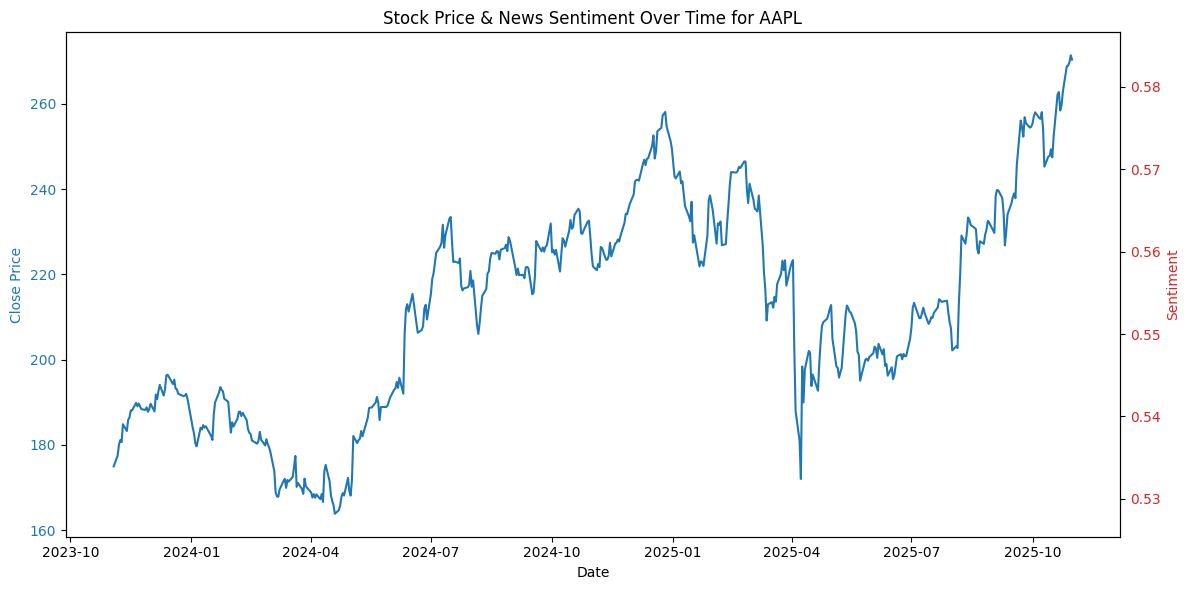

In [20]:
import matplotlib.pyplot as plt

def plot_sentiment_vs_price(df, symbol):
    fig, ax1 = plt.subplots(figsize=(12,6))

    ax1.set_xlabel('Date')
    ax1.set_ylabel('Close Price', color='tab:blue')
    ax1.plot(df['date'], df['Close'], color='tab:blue', label='Close Price')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    ax2 = ax1.twinx()
    ax2.set_ylabel('Sentiment', color='tab:red')
    ax2.plot(df['date'], df['sentiment'], color='tab:red', label='Sentiment', alpha=0.6)
    ax2.tick_params(axis='y', labelcolor='tab:red')

    plt.title(f'Stock Price & News Sentiment Over Time for {symbol}')
    fig.tight_layout()
    plt.show()

plot_sentiment_vs_price(combined_df, "AAPL")
